# Bernstein-Vazirani Algorithm

This notebook compares a classical query-based approach with the quantum Bernstein-Vazirani algorithm.
The goal is to recover a hidden bit string using as few oracle calls as possible.

The classical version needs one query per bit, while the quantum version can recover the full secret in a single oracle call.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

In [7]:
def classical_oracle(secret_string, query_string):
    """Simulates a classical oracle for the Bernstein-Vazirani problem."""
    return sum(int(s) * int(q) for s, q in zip(secret_string, query_string)) % 2

def classical_solver(secret_string):
    """Classically solves the Bernstein-Vazirani problem by querying the oracle."""
    n = len(secret_string)
    current_string = ""
    queries = 0
    
    for i in range(n):
        query_string = ['0'] * n
        query_string[i] = '1'
        query_str = "".join(query_string)
        
        result = classical_oracle(secret_string, query_str)
        current_string += str(result)
        queries += 1
    return current_string, queries

In [8]:
secret_s = "101101"
found_s, query_count = classical_solver(secret_s)
print(f"Classical solution found: {found_s} with {query_count} queries.")

Classical solution found: 101101 with 6 queries.


## Quantum Circuit

The Bernstein-Vazirani circuit prepares an ancilla qubit in |1>, places all qubits into superposition, and uses the oracle to imprint the hidden string onto phase information.
After the final Hadamard layer, measuring the first n qubits reveals the secret string directly.


## Classical Baseline

Before using the quantum circuit, this cell solves the same problem classically by querying the oracle once for each bit in the hidden string.
The result gives us a baseline for how many queries are required without quantum parallelism.


In [9]:
def bernstein_vazirani_circuit(secret_string):
    """Creates a quantum circuit for the Bernstein-Vazirani algorithm."""
    n = len(secret_string)
    qc = QuantumCircuit(n + 1, n)

    # Initialize the last qubit to |1>
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()

    # Apply the oracle
    secret_reversed = secret_string[::-1]
    for i in range(n):
        if secret_reversed[i] == '1':
            qc.cx(i, n)

    qc.barrier()
    
    # Apply Hadamard gates again
    qc.h(range(n))

    # Measure the first n qubits
    qc.measure(range(n), range(n))
    
    return qc

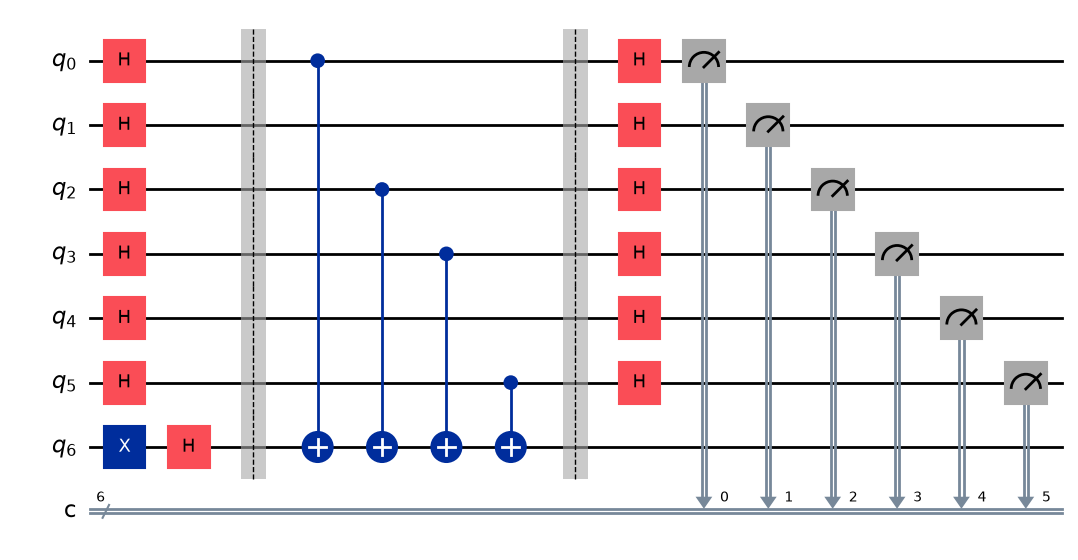

In [10]:
bernstein_vazirani_qc = bernstein_vazirani_circuit(secret_s)
bernstein_vazirani_qc.draw('mpl')

## Execute and Verify

This cell compiles the circuit for the Aer simulator and runs repeated shots.
Because the Bernstein-Vazirani algorithm is deterministic in the ideal case, the measured bit string should match the hidden secret string.


In [11]:
compiled_circuit = transpile(bernstein_vazirani_qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

print(f"Quantum Execution - State Probabilities: {counts}")

Quantum Execution - State Probabilities: {'101101': 1024}


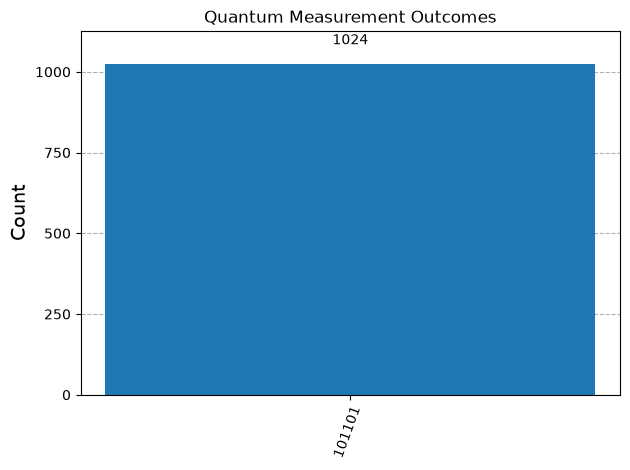

In [12]:
# Visualize the certainty of the result
plot_histogram(counts, title="Quantum Measurement Outcomes")

## Measurement Results

The histogram should show a single dominant outcome that matches the hidden string.
If the result is not perfectly sharp, that usually indicates simulator noise, circuit transpilation differences, or an earlier cell was run out of order.
